<a href="https://colab.research.google.com/github/PixelPusher8386/PythonPrograms/blob/main/%5BWS3%5D_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hands-On Workshop: Building and Training a Simple Neural Network
Welcome! In this notebook, we’ll train a simple neural network model to recognize clothing images.  

Steps we’ll follow:
1. Setup the environment  
2. Load and explore the dataset  
3. Build a simple neural network  
4. Train and evaluate the model  
5. Experiment with improvements


# Step 1: Setup
Libraries to import
- **TensorFlow / Keras** → Build and train the neural network  
- **NumPy** → Handle numbers and data  
- **Matplotlib** → Show images and graphs  

Keras is like a friendly interface that sits on top of TensorFlow.
Keras simplifies the process of building neural networks. Instead of writing hundreds of lines of complicated TensorFlow code, with Keras you can build a model in just a few lines.

Other options:

PyTorch → Developed by Facebook (now Meta). It’s very popular among researchers because it feels more flexible and feels natural for Python users.

MXNet → Backed by Amazon, used in cloud applications.

JAX → Also from Google, focuses on high-performance scientific computing and deep learning.


In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

# Check TensorFlow version (should be 2.x)
print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


# Step 2: Load and Explore the Dataset
We use the **Fashion-MNIST dataset**, which has 70,000 black-and-white images of clothes.  
- 60,000 images for training (teaching the model)  
- 10,000 images for testing (checking the model)  

### Why Normalize?
- Each image pixel has a value between 0 (black) and 255 (white).  
- Large numbers are harder for the model to process.  
- By dividing by 255, we shrink values into **0–1 range**, which makes learning easier, faster, and more accurate.

We also print dataset shapes and visualize some images to see what they look like.


In [ ]:
# Load Fashion-MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalize pixel values to 0-1 range (helps training)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Print shapes to understand the data
print(f"Training data shape: {x_train.shape} (60,000 images, 28x28 pixels)")
print(f"Test data shape: {x_test.shape}")
print(f"Labels: {np.unique(y_train)}")  # 0-9 for 10 classes

Training data shape: (60000, 28, 28) (60,000 images, 28x28 pixels)
Test data shape: (10000, 28, 28)
Labels: [0 1 2 3 4 5 6 7 8 9]


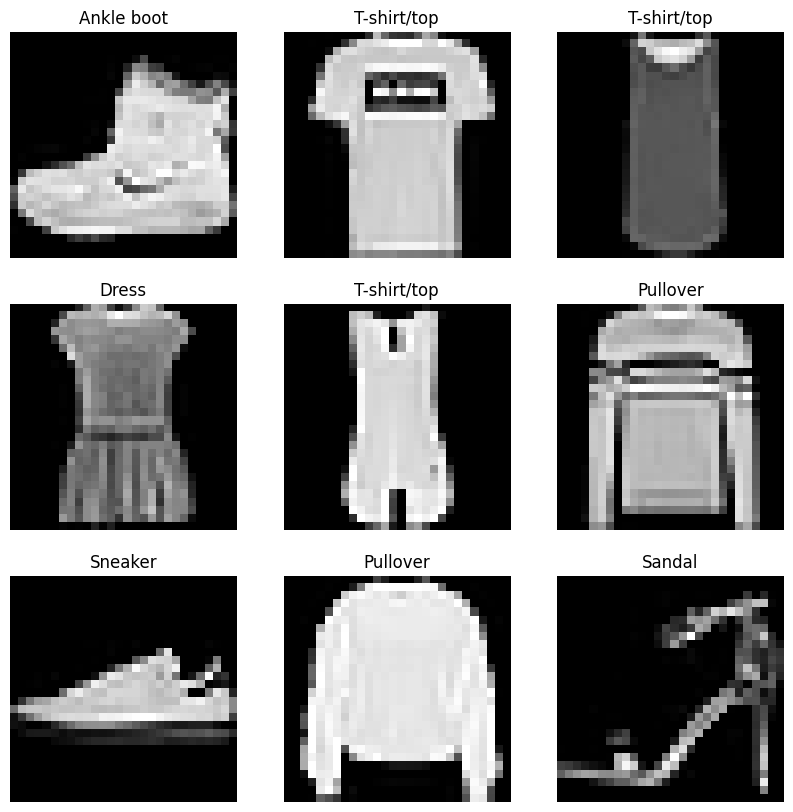

In [ ]:
# Class names for reference
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Plot first 9 images from training set
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.show()

#Step 3: Model Building

We create a simple model with three layers:  
1. **Flatten layer**: Turns 28x28 images into 784 numbers.  
2. **Hidden layer**: 128 neurons with ReLU activation (helps learn patterns).  
3. **Output layer**: 10 neurons (one for each clothing class) with softmax activation (turns outputs into probabilities summing to 1).  


In [ ]:
# Define the model
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),  # Input: Flatten 28x28 to 784
    keras.layers.Dense(128, activation='relu'),  # Hidden layer: 128 neurons, ReLU
    keras.layers.Dense(10, activation='softmax') # Output: 10 classes, softmax
])

The `model.summary()` command gives a table showing:

- **Layer types** (Flatten, Dense, etc.)  
- **Output shape** — how many numbers come out of each layer  
- **Parameters** — how many “trainable weights” are in the layer  

👉 These parameters are like dials the network adjusts while learning.  
In our case, the model has **~100,000 trainable parameters**, meaning 100k little pieces of knowledge it can tune to recognize clothing patterns.


In [ ]:
# Summary: Shows layers, parameters (~100k trainable weights!)
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

`model.compile()` to compile the model

What does compiling do?
- Defines:
  1. **Optimizer** → how weights are updated
  2. **Loss function** → what the model minimizes
  3. **Metrics** → how performance is measured


In [ ]:
model.compile(
    optimizer='adam',  # Adaptive optimizer, good default
    loss='sparse_categorical_crossentropy',  # For integer labels (0-9)
    metrics=['accuracy']  # Track % correct
)

#4. Training

- `model.fit` is the function that **trains** the model.
- It adjusts the model’s weights step by step to minimize the chosen loss function.

In [ ]:
# Train: Use 20% of training data for validation
history = model.fit(
    x_train, y_train,
    epochs=5,  # 5 full passes
    validation_split=0.2,  # 20% for validation
    verbose=1  # Show progress
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7724 - loss: 0.6611 - val_accuracy: 0.8543 - val_loss: 0.4127
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8568 - loss: 0.4008 - val_accuracy: 0.8660 - val_loss: 0.3742
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8710 - loss: 0.3531 - val_accuracy: 0.8755 - val_loss: 0.3451
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8835 - loss: 0.3204 - val_accuracy: 0.8691 - val_loss: 0.3563
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8900 - loss: 0.2998 - val_accuracy: 0.8767 - val_loss: 0.3528


# Training vs Validation Loss

## Training Loss
- Error on the **training set** (data the model is learning from).
- Decreases as the model adjusts its weights.

## Validation Loss
- Error on the **validation set** (data not used in training).
- Shows how well the model generalizes.
- Key for detecting **overfitting**:
  - Training loss ↓, Validation loss ↑ → Overfitting



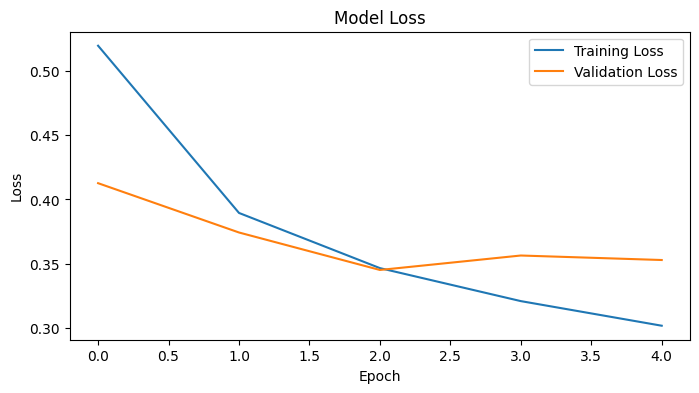

In [ ]:
# Plot training & validation loss
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

`model.evaluate(x_test, y_test)`
- Runs the trained model on **test set** (completely new data).
- Returns:
  - **Test loss** → error on test set
  - **Test accuracy** → % of correct predictions

In [ ]:
# Evaluate
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.1f}%)")

Test Accuracy: 0.8637 (86.4%)


# Learn through Experiments

## Base Model (Reference)
- Hidden layer: `Dense(128, activation='relu')`
- Balanced: strong enough to learn patterns, efficient to train
- Accuracy: ~85–87%

In [ ]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])
# Re-compile and train as before

# 1. Reduce Neurons

- Change: `Dense(64, 'relu')`
- Effect:
  - Fewer neurons → simpler, faster model
  - Lower capacity → accuracy drops (~83%)
- Why not use 64 in base model?
  - 128 neurons provide a better balance of power and efficiency

In [ ]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation='softmax')
])
# Re-compile and train as before (run the code cells below)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer='adam',  # Adaptive optimizer, good default
    loss='sparse_categorical_crossentropy',  # For integer labels (0-9)
    metrics=['accuracy']  # Track % correct
)

In [ ]:
# Train: Use 20% of training data for validation
history = model.fit(
    x_train, y_train,
    epochs=5, #5 full passes
    validation_split=0.2,  # 20% for validation
    verbose=1  # Show progress
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7067 - loss: 0.8369 - val_accuracy: 0.8416 - val_loss: 0.4503
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8274 - loss: 0.4825 - val_accuracy: 0.8513 - val_loss: 0.4073
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8400 - loss: 0.4446 - val_accuracy: 0.8596 - val_loss: 0.3820
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8479 - loss: 0.4202 - val_accuracy: 0.8684 - val_loss: 0.3577
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8496 - loss: 0.4108 - val_accuracy: 0.8690 - val_loss: 0.3572


In [ ]:
# Evaluate
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.1f}%)")

Test Accuracy: 0.8613 (86.1%)


# 2. ReLU vs Sigmoid

- Change: `Dense(128, 'sigmoid')`
- Effect:
  - Sigmoid squashes values between 0 and 1
  - Can cause vanishing gradients → slower learning
  - Typically lower accuracy than ReLU

In [ ]:
# In model definition
keras.layers.Dense(128, activation='sigmoid')

<Dense name=dense_15, built=False>

# 3. Add Dropout

- Change: `Dense(128, 'relu')` + `Dropout(0.5)`
- Effect:
  - Randomly ignores 50% of neurons during training
  - Reduces reliance on specific neurons
  - Helps prevent **overfitting**
  - More important for larger, complex datasets

In [ ]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),  # Add here
    keras.layers.Dense(10, activation='softmax')
])

- **Number of neurons**: controls learning capacity
- **Activation function**: affects how information flows and how fast learning happens
- **Dropout**: improves generalization by preventing overfitting